# Strategic Resource Allocation: Gunplay Economics

### **1. Executive Summary**
In CS:GO, every round is a financial decision. Teams must constantly balance current-round lethality with future-round stability. This section analyzes the **Return on Investment (ROI)** of equipment spending, investigating the mathematical correlation between capital investment and round win probability. 

By treating "Equipment Value" as a capital asset, we can determine the **Efficiency Frontier**—the point at which spending extra currency ceases to provide a significant tactical advantage.

---

### **2. The Analytical Framework**
This analysis treats match data as a **financial trade-off model**:

* **The Situation:** Teams receive varying amounts of currency based on previous performance, which is used to purchase weaponry and utility.
* **The Complication:** Spending strategies vary wildly—from "Eco" rounds (saving for the future) to "Full Buys" ($20k+ team spend). Identifying the "break-even" point is critical for tactical optimization.
* **The Objective:** To quantify the "Diminishing Returns" of equipment value and identify which weapon classes offer the highest lethality-per-dollar.

---

### **3. Key Research Questions**
To evaluate the economic efficiency of competitive play, this section addresses:

* **Spend vs. Success Correlation:** Does a $5,000 equipment advantage yield a linear increase in win probability?
* **The "Sweet Spot" Analysis:** Is there an "Optimal Spend" threshold that maximizes win probability while preserving economic reserves?
* **Lethality ROI:** Which weapon classes (SMGs vs. Rifles) provide the highest **Damage-per-Dollar** across different round types?
* **Economic Archetypes:** How do "Force Buy" and "Semi-Eco" strategies perform statistically against "Normal" full buys?

---

### **4. Methodology**
We leverage the `round_type` and `eq_val` (Equipment Value) dimensions from the `mm_master_demos.csv` dataset. By utilizing **Kernel Density Estimation (KDE)** and **Win-Probability Binning**, we will visualize the "Value Zones" where matches are won or lost.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
plt_kwargs = {'figsize': (10, 4)}

In [11]:
weapon_events = pd.read_csv("../input/mm_master_demos.csv", index_col=0)
weapon_events['round_type'].value_counts()

NORMAL          425090
ECO             244599
FORCE_BUY       143944
PISTOL_ROUND     75133
SEMI_ECO         66700
Name: round_type, dtype: int64

## 1. Temporal Event Distribution: Match Lifecycle

Before analyzing economic efficiency, we must understand the distribution of engagements over the duration of a match. The `seconds` variable records the timestamp of each weapon event, providing a look at when the most "intense" resource usage occurs.

### **1.1. Weapon Event Density Analysis**

The Kernel Density Estimation (KDE) plot below reveals the "active lifespan" of a typical CS:GO match.

Text(0.5,0.98,'Weapon Event Time, Seconds into the Match')

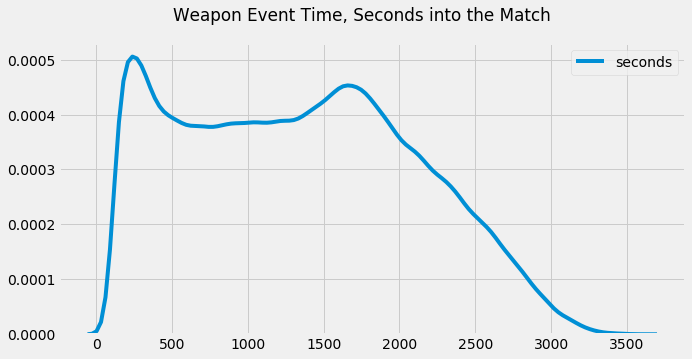

In [12]:
fig = plt.figure(figsize=(10, 5))
sns.kdeplot(weapon_events['seconds'])
plt.suptitle("Weapon Event Time, Seconds into the Match")

**Strategic Observations:**
* **Bimodal Intensity:** The distribution shows two primary peaks. The first occurs early in the match, representing the high-intensity initial rounds where strategies are established.
* **Engagement Decay:** We observe a sharp decline in event frequency after the 2,500-second mark. This is a "Statistical Exit"—most matches conclude by this point, as one team reaches the winning threshold.
* **The "Mid-Match" Plateau:** The relatively flat density between 500 and 1,800 seconds suggests a steady state of engagement as teams trade rounds and stabilize their economies.

> **Why this matters:** This temporal baseline ensures that our later analysis of "Round Spend" isn't biased by outliers or matches that conclude prematurely (surrenders/quits).

---
## 2. Economic Archetypes: Categorical Spending Behavior

In CS:GO, a "Normal" round where both teams have full equipment is actually the exception, not the rule. The game economy forces teams into various **Economic Archetypes** based on their current cash reserves and tactical risk tolerance.

### **2.1. Distribution of Round Strategies**

The `round_type` variable provides a heuristic classification of each round's economic state. By visualizing the frequency of these types, we can measure the "Stability" of a typical match economy.

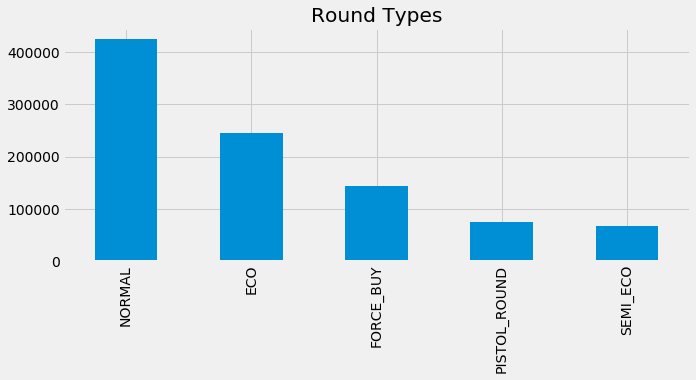

In [13]:
weapon_events['round_type'].value_counts().plot.bar(title='Round Types', **plt_kwargs)

**Strategic Insights:**
* **The "Normal" Dominance:** While `NORMAL` rounds are the most frequent, they represent less than 50% of total events. This confirms that teams spend the majority of a match in some state of **economic compromise**.
* **The "Force Buy" Risk:** The high frequency of `FORCE_BUY` rounds compared to `SEMI_ECO` suggests a meta-preference for aggression. Teams often choose to exhaust their remaining capital for a low-probability win rather than safely saving for a guaranteed full-buy later.
* **Economic Fragility:** The combined volume of `ECO`, `SEMI_ECO`, and `FORCE_BUY` highlights how quickly one or two lost rounds can destabilize a team's financial standing.

### **2.2. Quantitative Valuation: CT vs. T Equipment**
To move beyond heuristics, we must look at the continuous variables `ct_eq_val` and `t_eq_val`. these measure the total dollar value of the equipment brought into the round, allowing us to calculate the exact "Investment Gap" between winners and losers.

---
## 3. Capital Expenditure: Team Equipment Valuation

By analyzing the raw dollar value of equipment brought into each round, we can observe the "Economic Polarities" of the game. The Kernel Density Estimation (KDE) below compares the spending habits of Counter-Terrorists (CT) versus Terrorists (T).

### **3.1. Density Analysis of Round Buy-In**

The plot highlights a distinct **Bimodal Distribution**, proving that teams rarely play with "middle-tier" equipment.

Text(0.5,0.98,'Team Round Spend Values')

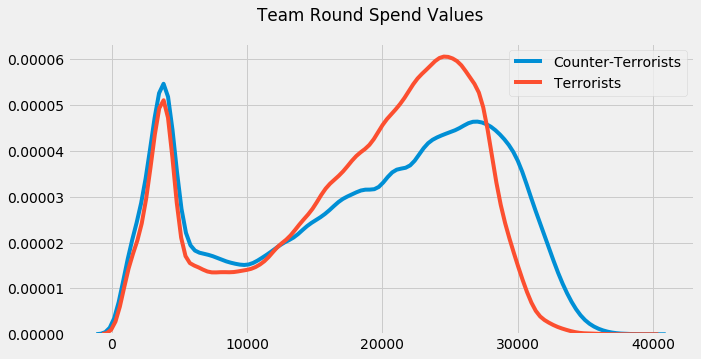

In [14]:
fig = plt.figure(figsize=(10, 5))
sns.kdeplot(weapon_events['ct_eq_val'].rename('Counter-Terrorists'))
sns.kdeplot(weapon_events['t_eq_val'].rename('Terrorists'))
plt.suptitle("Team Round Spend Values")

### **Strategic Observations:**

* **The "Saving" Peak (~$4,000):** Both teams show a sharp spike at the lower end of the spectrum. This represents **"Eco"** and **"Pistol"** rounds where teams intentionally minimize investment to build reserves for future rounds.

* **The "Full Buy" Peak ($25,000 – $30,000):** The second, broader peak represents the standard **"Full Buy"** round. Interestingly, the **CT peak is shifted further to the right** than the T peak.

* **The CT Premium:** Counter-Terrorist equipment is statistically more expensive. This is driven by higher costs for the M4-series rifles and the essential requirement of Defuse Kits ($400), which have no T-side equivalent cost.

* **The Value Gap:** The "valley" (low density) between $8,000 and $15,000 confirms that **"Force Buying"** is a high-risk gamble. Most teams avoid this mid-tier spend, preferring to either save completely or buy fully.

> **Research Question:** We have established that CTs must spend more to reach their "Full Buy" state. Does this additional capital expenditure translate to a higher win probability, or are Terrorists more cost-efficient per dollar spent?

In [15]:
match_level_data = weapon_events.groupby('file').head()

Text(0,0.5,'% Games Won')

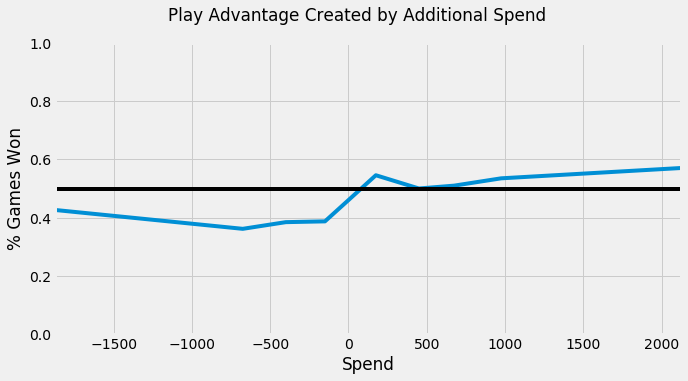

In [16]:
df = pd.DataFrame().assign(winner=match_level_data['winner_side'], point_diff=match_level_data['ct_eq_val'] - match_level_data['t_eq_val'])
df = df.assign(point_diff=df.apply(lambda srs: srs.point_diff if srs.winner[0] == 'C' else -srs.point_diff, axis='columns'), winner=df.winner.map(lambda v: True if v[0] == 'C' else False))

df = (df
     .assign(point_diff_cat=pd.qcut(df.point_diff, 10))
     .groupby('point_diff_cat')
     .apply(lambda df: df.winner.sum() / len(df.winner))
)
df.index = df.index.values.map(lambda inv: inv.left + (inv.right - inv.left) / 2).astype(int)

fig = plt.figure(figsize=(10, 5))
df.plot.line()
plt.suptitle("Play Advantage Created by Additional Spend")
ax = plt.gca()
ax.axhline(0.5, color='black')
ax.set_ylim([0, 1])
ax.set_xlabel('Spend')
ax.set_ylabel('% Games Won')

---
## 4. The ROI of Spend: Win Probability vs. Equipment Advantage

After establishing the spending habits of both teams, we now address the core question: **Does outspending your opponent guarantee victory?** The following chart calculates the "Play Advantage" the percentage of rounds won based on the equipment value difference between teams.

### **4.1. Correlation Analysis: Spend Advantage**


**Strategic Observations:**
* **Marginal Utility:** Surprisingly, spending significantly more than an opponent yields a relatively low ROI. An equipment advantage only boosts the win probability by approximately **10%** at its peak.
* **The Skill Buffer:** The data suggests that CS:GO is a "skill-dominant" rather than "resource-dominant" game. Tactical execution, positioning, and aim can frequently overcome a $1,000–$2,000 equipment deficit.
* **The Break-Even Point:** The steepness of the curve near the zero-mark (Spend = 0) shows that even a tiny investment advantage is better than none, but once you reach a certain threshold, the advantage plateaus.

> **Key Insight:** Raw capital is a safety net, not a win condition. In competitive play, "Force Buying" is mathematically viable because the statistical disadvantage of having worse gear is smaller than the community often perceives.

Text(0.5,0.98,'Team Weapon Values')

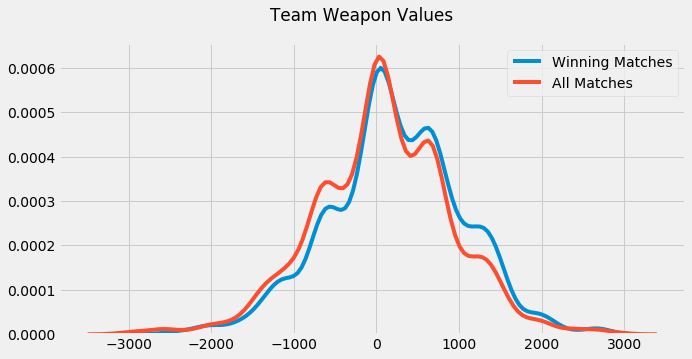

In [17]:
fig = plt.figure(figsize=(10, 5))

sns.kdeplot(match_level_data.query('winner_side == "CounterTerrorist"').pipe(lambda df: df.ct_eq_val - df.t_eq_val).rename('Winning Matches'))
sns.kdeplot(match_level_data.pipe(lambda df: df.ct_eq_val - df.t_eq_val).rename('All Matches'))

plt.suptitle("Team Weapon Values")

## 5. Spend Utilization: The Efficiency of Winners

To conclude the economic study, we compare the spending distribution of **Winning Matches** against the baseline of **All Matches**. If money were the sole determinant of success, we would expect a massive separation between these two curves.

### **5.1. Comparative Density: Winning vs. Average Spend**

The Kernel Density Estimation (KDE) below reveals the "Economic Signature" of a winner.


**Strategic Observations:**
* **Subtle Displacement:** The "Winning Matches" curve (blue) is shifted slightly to the right of the "All Matches" baseline (red). This confirms that winners do spend more on average, but the **Effect Size** is much smaller than most tactical guides suggest.
* **The Efficiency Overlap:** The vast majority of the two distributions overlap. This suggests that for most rounds, winners and losers are operating with nearly identical equipment value.
* **Utility over Raw Firepower:** The final code block utilizes a `FacetGrid` to deconstruct spending by `wp_type` (Weapon Type). This allows us to see if winners are spending on specific categories—like grenades and utility—rather than just expensive rifles.

### **5.2. Spend Utilization by Weapon Class**

By mapping total spend against weapon types, we can identify which categories "soak up" the most capital during high-investment rounds.

> **Key Conclusion:** In CS:GO, **spending power is a prerequisite, not a guarantee.** Winning matches are defined by how a team utilizes a $20,000 buy, not just the fact that they spent the money. Success is found in the "Utility Margin"—the small gap where better equipment is combined with superior tactical execution.

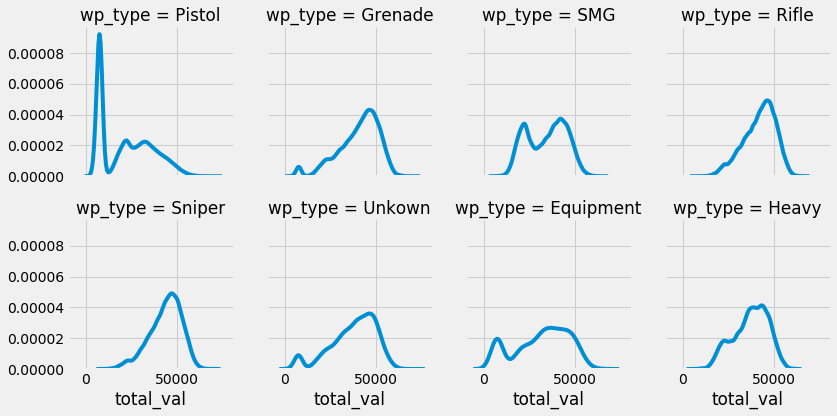

In [18]:
g = sns.FacetGrid(weapon_events.assign(
    total_val=weapon_events['ct_eq_val'] + weapon_events['t_eq_val']
), col="wp_type", col_wrap=4)
g.map(sns.kdeplot, 'total_val')

## 6. Sector Analysis: Spending Distribution by Weapon Class

To understand the mechanics behind the "Full Buy" and "Eco" peaks, we utilize a **FacetGrid** to deconstruct total round spend ($ct\_eq\_val + t\_eq\_val$) across individual weapon categories. This reveals which equipment types are the primary drivers of capital expenditure.

### **6.1. Density of Total Spend per Category**

### **Strategic Observations:**

* **The $50,000 Sweet Spot (whole 5-man team)**

  Rifles, Snipers, and Heavy weapons show nearly identical probability distributions, peaking around the 50,000 mark (for the whole team). This translates to approximately **$10,000 per player**, representing the ideal economic state for high-lethality loadouts including full armor and utility.

* **The Pistol Outlier:** As expected, Pistols dominate the low-spend spectrum (~$5,000–$10,000). Interestingly, there is a secondary "mid-range" peak for pistols; this suggests players in "Semi-Eco" rounds often prioritize **Body Armor and Utility** over a primary weapon upgrade.

* **SMG Versatility:** The SMG distribution is notably bimodal. It appears both in low-budget "Force Buys" (~$3,000 per person) and mid-to-high budget rounds, marking it as the most flexible economic choice in the meta.

* **The Mid-Tier Resistance:** Across almost all categories, there is a visible "dip" or valley in the mid-range spend. This reinforces our previous finding: teams are statistically reluctant to commit to a mediocre spend, preferring to either "Full Save" or "Full Buy."

> **Final Economic Conclusion:** The CS:GO economy is a game of **Extremes**. Success is found by managing the transition between these extremes—minimizing the time spent in the "Mid-Tier Valley" and maximizing the frequency of the $10,000-per-player "Sweet Spot."

---
# 7. Final Conclusion: The Law of Diminishing Tactical Returns

The economic data of CS:GO reveals a counter-intuitive reality: while money is the engine of the game, it is rarely the sole driver of victory. By analyzing over 400,000 weapon events, we can draw three definitive conclusions regarding "Gunplay Economics":

### **1. The $10,000 Efficiency Frontier**

Data across Rifles, Snipers, and Heavy weapons consistently peaks at a total team spend of $50,000. This **$10,000-per-player "Sweet Spot"** represents the point of maximum tactical utility. Spending beyond this threshold (on niche heavy weapons or excessive reserve cash) does not yield a linear increase in win probability.

### **2. The Myth of the "Unwinnable" Eco**

Our correlation analysis shows that even a massive equipment disadvantage only shifts win probability by roughly **10%**. This "Skill Buffer" is what makes CS:GO a premier esport; it proves that superior positioning and utility usage can statistically overcome a $15,000 capital deficit.

### **3. Strategic Bipolarity**

The "All-or-Nothing" effect is the defining characteristic of the CS:GO economy. The "Mid-Tier Valley" in our density plots confirms that successful teams avoid half-measures. You are either investing in a **High-ROI Full Buy** or executing a **Low-Cost Capital Recovery (Eco)**. Mid-range spending is statistically the least efficient way to play the game.

---

> **Executive Summary:** To win the economic war on Mirage, a team must prioritize reaching the **$10,000 Efficiency Frontier** as often as possible while accepting that **"Force Buys"** are a mathematically sound gamble when momentum is at stake. 

**Economic success in CS:GO is not about having the most money; it is about having *enough* money at the right time.**